In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
## general libraries
import pathlib
from rich.pretty import install, pprint
from loguru import logger

## data handling libraries
import numpy as np
import pandas as pd
import xarray as xr
from tqdm.dask import TqdmCallback as ProgressBarDask

# plotting libraries
import matplotlib.pyplot as plt
import hvplot.xarray
import panel

## machine learning libraries
import gpytorch 
import torch
import ngboost
from sklearn import metrics
from sklearn import ensemble as trees

## PAMIR libraries
import mlflow
import hydra
import pamir_mlpermafrost as pamir
from cryogrid_pytools import xr_raster_vector

ngb = pamir.models.ngb

install(overflow=True)

In [3]:
def plot_profile(da, **props):

    x = da.values.T
    y = -da.depth.values

    if 'ax' not in props:
        fig, ax = plt.subplots(figsize=(4, 6))
    else:
        ax = props.pop('ax')
    
    ax.plot(x, y, **props)

    return ax

# Get data

In [4]:
s3_path = 's3://spi-pamir-cryogrid/pamir-MLpermafrost/data-output/ngboost-single_depth-cv_tuning/pamir-ngboost-ground_temp.zarr/'
ds = pamir.data.open_s3zarr(s3_path)
da = ds.yhat_ngboost
da_season_diff = da.diff(dim='season').isel(season=0, drop=True)

with ProgressBarDask():
    da_summer = ds.yhat_ngboost.sel(season='JAS', drop=True)
    da_winter = ds.yhat_ngboost.sel(season='JFM', drop=True)
    da_uncert_summer = ds.ystd_ngboost.sel(season='JAS', drop=True)
    da_uncert_winter = ds.ystd_ngboost.sel(season='JAS', drop=True)

In [5]:
s3_url_freeze_prob = "s3://spi-pamir-cryogrid/pamir-MLpermafrost/data-output/pamir-ground_temp-freeze_probability.zarr/"

da_freeze_prob = pamir.data.open_s3zarr(s3_url_freeze_prob).freezing_probability
with ProgressBarDask():
    prob_summer = da_freeze_prob.sel(season='JAS').interp(depth=np.arange(0, 18.1, 0.2), method='cubic')

In [6]:
s3_path = "s3://spi-pamir-cryogrid/pamir-MLpermafrost/data-inference/inference_variables-710w365s750e400n-100m.zarr/"
spatial = pamir.data.open_s3zarr(s3_path)
mask = (spatial.land_cover.interp_like(da) > 1)

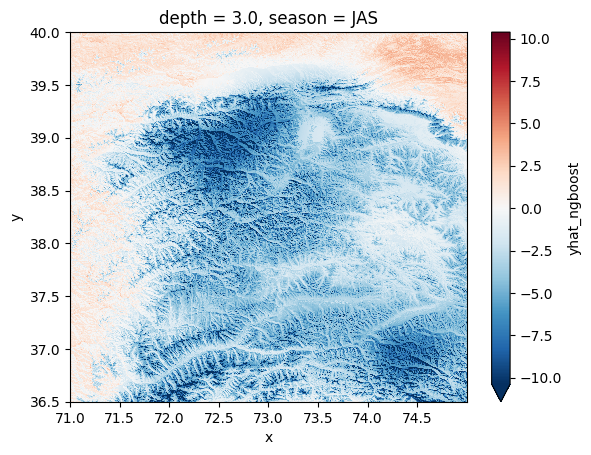

In [26]:
ds.yhat_ngboost.sel(season='JAS', depth=3).plot.imshow(robust=True)

# Compute ALT

In [11]:
with ProgressBarDask():
    da_summer_interp = (
        da_summer
        .interp(depth=np.arange(0, 10.1, 0.1), method='cubic')
        .bfill('depth'))

    has_positive = (da_summer_interp > 0).any('depth')
    has_negative = (da_summer_interp < 0).any('depth')
    crosses_0 = (has_positive & has_negative)

    active_layer_thickness = (
        da_summer_interp
        .where(crosses_0)
        .pipe(abs)
        .idxmin('depth')
        .rename('active_layer_thickness')
        .assign_attrs(
            long_name='Active layer thickness',
            units='m')
        .persist())

  0%|          | 0/11378 [00:00<?, ?it/s]

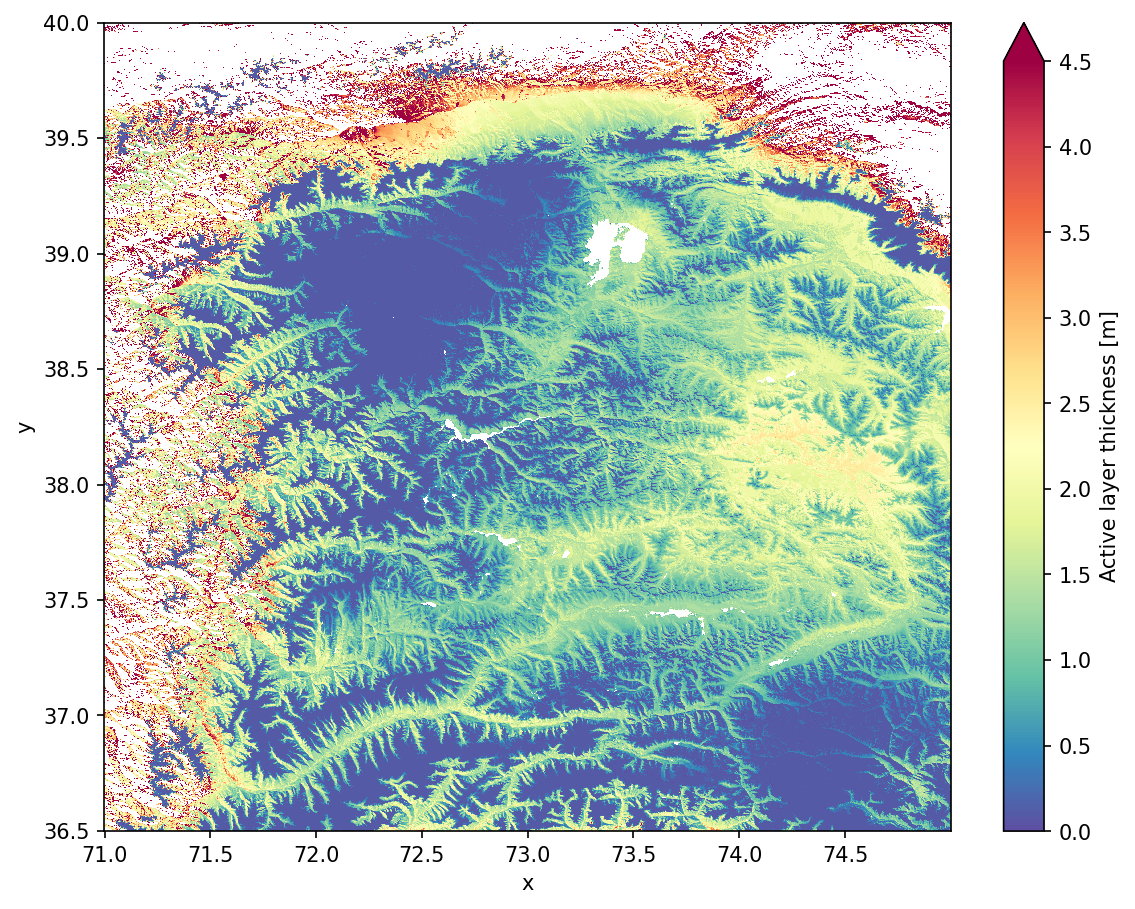

In [12]:
img = (
    active_layer_thickness
    .fillna(0.1)
    .where(has_negative & mask)
    .plot.imshow(vmin=0, vmax=4.5, size=7, aspect=1.3, cmap='Spectral_r')
)

img.figure.set_dpi(150)

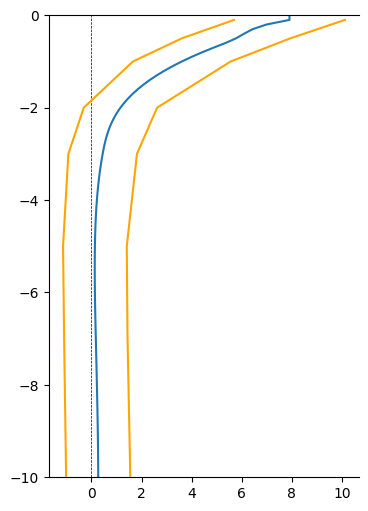

In [14]:
point = dict(y=37, x=71.2, method='nearest')

da = da_summer_interp.sel(**point)
da_uncert = da_uncert_summer.sel(**point)

da_lower = da - da_uncert
da_upper = da + da_uncert

ax = da.pipe(plot_profile, color='C0')
da_lower.pipe(plot_profile, color='orange', ax=ax)
da_upper.pipe(plot_profile, color='orange', ax=ax)

ax.axvline(0, c='k', ls='--', lw=0.5, zorder=0)
ax.set_ylim(-10, 0)

ax.spines['right'].set_visible(False)

# Probability

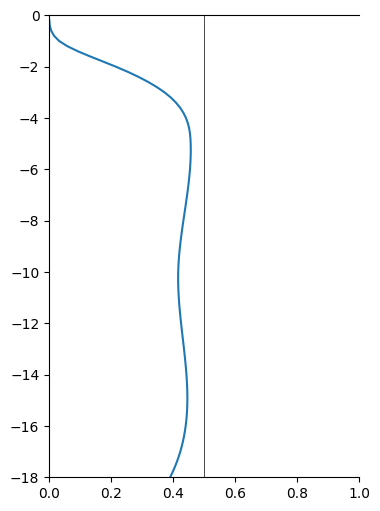

In [15]:
da = prob_summer.sel(**point)
ax = da.pipe(plot_profile)
ax.set_xlim(0, 1)
ax.axvline(0.5, c='k', lw=0.5)
ax.set_ylim(-18, 0)

ax.spines['right'].set_visible(False)

  0%|          | 0/3759 [00:00<?, ?it/s]

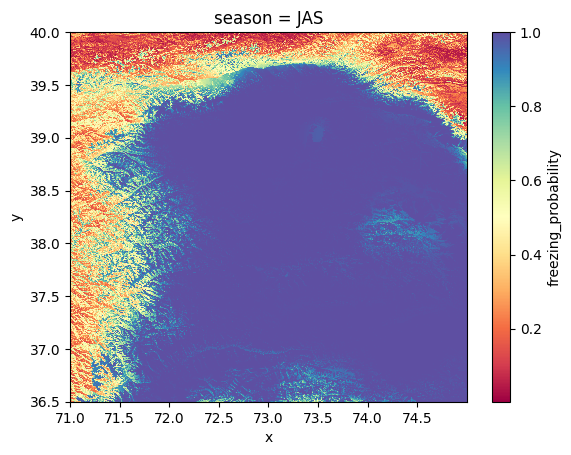

In [17]:
with ProgressBarDask():
    prob_summer.sel(depth=slice(6, 20)).min('depth').plot.imshow(cmap='Spectral')

In [ ]:
with ProgressBarDask():
    frozen90_depth = (prob_summer > 0.9).idxmax('depth').where(frozen90.any('depth')).compute()
    frozen10_depth = (prob_summer > 0.1).idxmax('depth').where(frozen90.any('depth')).compute()

  0%|          | 0/4551 [00:00<?, ?it/s]

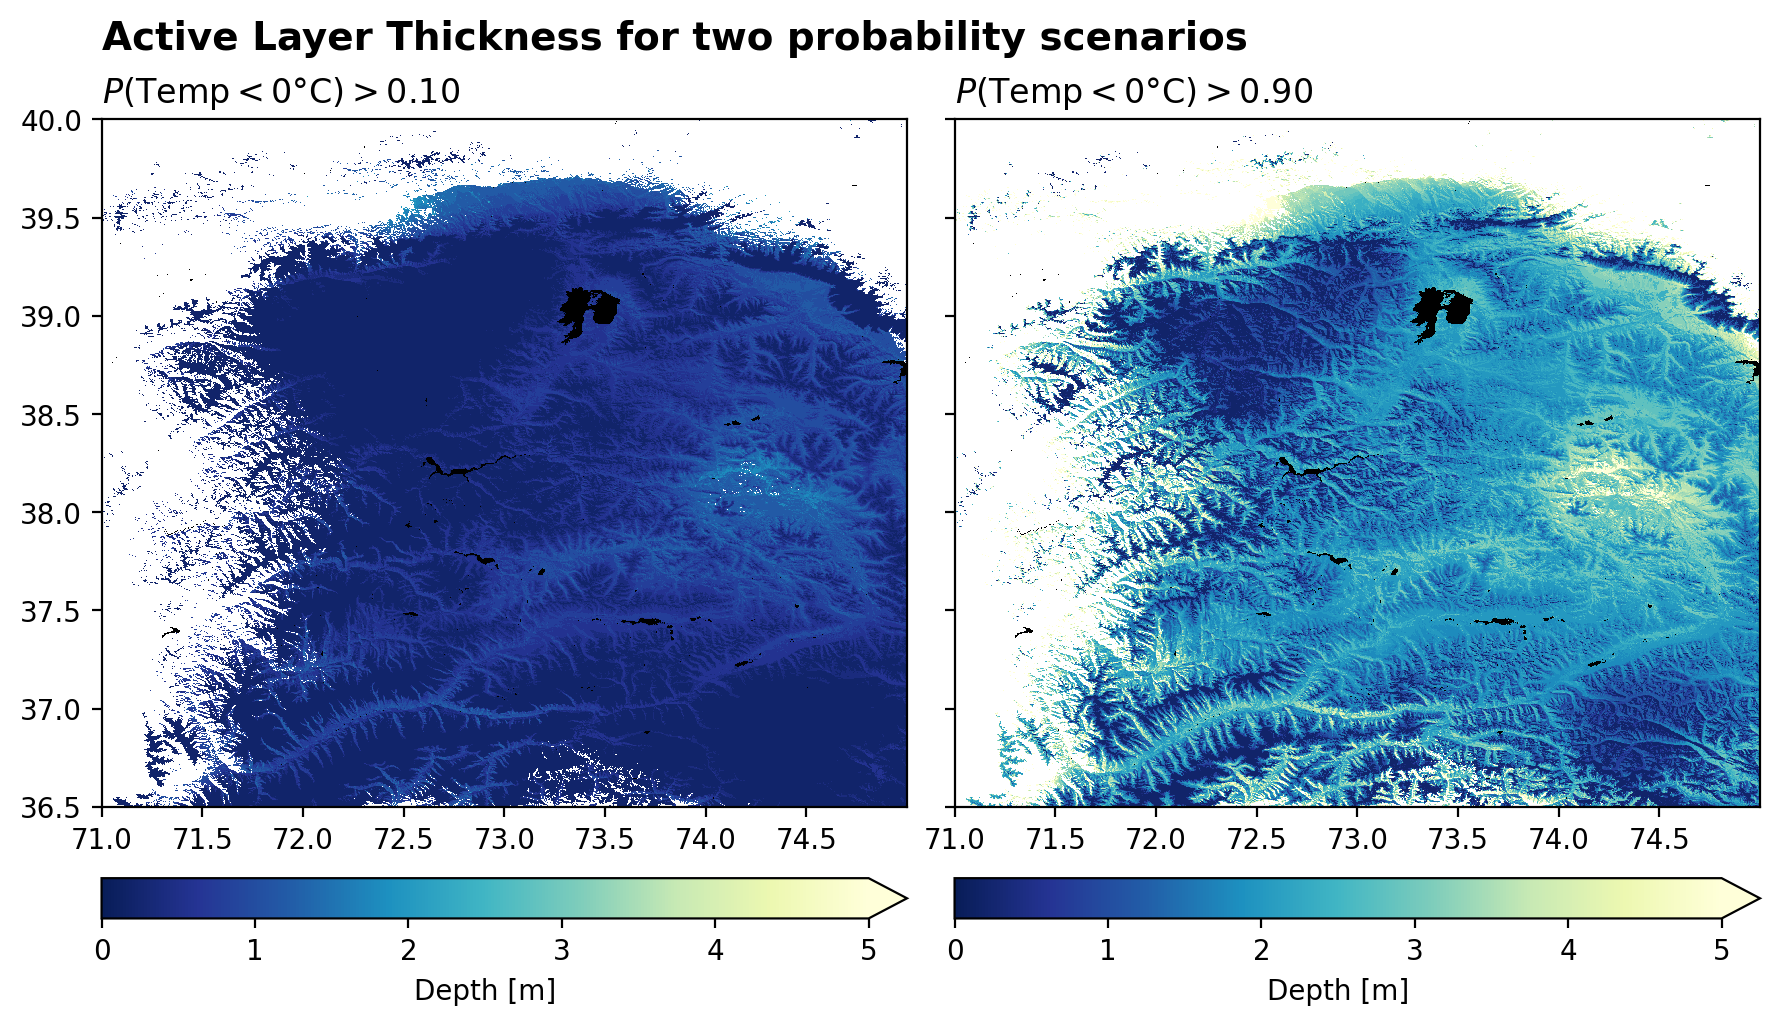

In [59]:
fig, axs = plt.subplots(1, 2, figsize=[9, 5], sharey=True, dpi=200)

props = dict(cmap='YlGnBu_r', vmin=0, vmax=5, cbar_kwargs={'location': 'bottom', 'label': 'Depth [m]', 'pad': 0.08, 'extend': 'max'})
frozen10_depth.load().plot.imshow(ax=axs[0], **props)
frozen90_depth.load().plot.imshow(ax=axs[1], **props)

mask.where(~mask).plot.imshow(ax=axs[0], cmap='bone', vmin=0, vmax=1, add_colorbar=False)
mask.where(~mask).plot.imshow(ax=axs[1], cmap='bone', vmin=0, vmax=1, add_colorbar=False)

for ax in axs:
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title('')
    
axs[0].set_title('$P(\\text{Temp} < 0°\\text{C}) > 0.10$', loc='left')
axs[1].set_title('$P(\\text{Temp} < 0°\\text{C}) > 0.90$', loc='left')

fig.tight_layout()

p0 = axs[0].get_position()
fig.suptitle('Active Layer Thickness for two probability scenarios', x=p0.x0, ha='left', y=p0.y1 + 0.1, size=14, weight='bold')

plt.show()